In [1]:
# ============================================================
# CELL 1 — Install Dependencies
# ============================================================
!pip install shap pyarrow --quiet
print('✅ Dependencies installed')

✅ Dependencies installed


In [3]:
# ============================================================
# CELL 2 — GPU Setup
# ============================================================
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'✅ GPU detected: {gpus}')
else:
    print('⚠️  No GPU found, running on CPU')

✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
# ============================================================
# CELL 3 — Imports
# ============================================================
import numpy as np
import pandas as pd
import json
import joblib
import gc
import os
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam

print('✅ All imports successful')

✅ All imports successful


In [5]:
# ============================================================
# CELL 4 — Paths
# ============================================================
# ── Dataset paths
DATASET_PATH = '/kaggle/input/datasets/muhammadasad29/ember24/New folder'
TRAIN_PATH   = f'{DATASET_PATH}/ember24_win64_train.parquet'
TEST_PATH    = f'{DATASET_PATH}/ember24_win64_test.parquet'

# ── Feature columns JSON (used for aligning features across clients)
# Using the central model's feature cols as the reference/union set
FEATURE_COLS_JSON = '/kaggle/input/datasets/muhammadasad29/ember24-feature-cols/ember24_client1_feature_cols.json'

# ── Client model directories on Kaggle input
# Adjust these paths to wherever you uploaded client artifacts
CLIENT_DIR = '/kaggle/input/models/muhammadasad29/ember24/keras/default/1'

# Each client must have: client_N_weights.weights.h5, client_N_scaler.pkl, client_N_feature_cols.json
# Define client IDs present
CLIENT_IDS = [1, 2]   # ← update if you have more/fewer clients

# ── Output directory
OUT_DIR = '/kaggle/working'
os.makedirs(OUT_DIR, exist_ok=True)

print('✅ Paths configured')

✅ Paths configured


In [20]:
# ============================================================
# CELL 5 — Helper: Build Model Architecture
# ============================================================
def build_mlp(n_features: int) -> tf.keras.Model:
    """Recreate the same MLP used during client training."""
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_mlp_from_client(client_id: int) -> tf.keras.Model:
    """
    Load the full client .keras model and return it recompiled.
    Used when weight tensor count doesn't match build_mlp().
    """
    keras_path = f'{CLIENT_DIR}/ember24_client{client_id}_mlp.keras'
    model = tf.keras.models.load_model(keras_path)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    print(f'   Client {client_id} model has {len(model.weights)} weight tensors')
    return model

print('✅ build_mlp() and build_mlp_from_client() defined')

✅ build_mlp() and build_mlp_from_client() defined


In [7]:
# ============================================================
# CELL 6 — Helper: Clean NaN / Inf with Median
# ============================================================
def clean_nan_inf(X: np.ndarray, col_medians: np.ndarray = None):
    """
    Replace inf with nan, then fill nan with column median.
    If col_medians is None, compute from X (training set).
    Returns (X_clean, col_medians).
    """
    X = np.where(np.isinf(X), np.nan, X)
    if col_medians is None:
        col_medians = np.nanmedian(X, axis=0)
    for i in range(X.shape[1]):
        mask = np.isnan(X[:, i])
        if mask.any():
            X[mask, i] = col_medians[i]
    return X, col_medians

print('✅ clean_nan_inf() defined')

✅ clean_nan_inf() defined


In [8]:
# ============================================================
# CELL 7 — Load Reference Feature Columns (for alignment)
# ============================================================
with open(FEATURE_COLS_JSON, 'r') as f:
    reference_feature_cols = json.load(f)

print(f'✅ Reference feature columns loaded: {len(reference_feature_cols)} features')
print(f'   First 5: {reference_feature_cols[:5]}')

✅ Reference feature columns loaded: 890 features
   First 5: ['byteentropy_0', 'byteentropy_1', 'byteentropy_10', 'byteentropy_100', 'byteentropy_101']


In [9]:
# ============================================================
# CELL 8 — Load Train & Test Data
# ============================================================
print('Loading train set...')
train_df = pd.read_parquet(TRAIN_PATH)
print('Loading test set...')
test_df  = pd.read_parquet(TEST_PATH)

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')

Loading train set...
Loading test set...
Train shape : (720000, 898)
Test  shape : (160000, 945)


In [10]:
# ============================================================
# CELL 9 — Detect Label Column & Filter Unlabeled Rows (-1)
# ============================================================
LABEL_COL = None
for col in train_df.columns:
    if col.lower() == 'label':
        LABEL_COL = col
        break

if LABEL_COL is None:
    raise ValueError('❌ Label column not found. Check dataset.')

print(f'✅ Label column: "{LABEL_COL}"')
print('\nTrain distribution (before filter):')
print(train_df[LABEL_COL].value_counts())

# Remove unlabeled rows
train_df = train_df[train_df[LABEL_COL] != -1].reset_index(drop=True)
test_df  = test_df[test_df[LABEL_COL]   != -1].reset_index(drop=True)

print(f'\nAfter filter — Train: {train_df.shape}, Test: {test_df.shape}')

✅ Label column: "label"

Train distribution (before filter):
label
1    360000
0    360000
Name: count, dtype: int64

After filter — Train: (720000, 898), Test: (160000, 945)


In [11]:
# ============================================================
# CELL 10 — Align Features: Keep Only Reference Columns
# ============================================================
# Only keep columns that exist in dataset AND the reference JSON
feature_cols = [c for c in reference_feature_cols
                if c in train_df.columns and c in test_df.columns]

print(f'✅ Aligned feature columns: {len(feature_cols)}')
if len(feature_cols) == 0:
    raise ValueError('❌ No overlapping feature columns. Check JSON path and dataset.')

✅ Aligned feature columns: 890


In [12]:
# ============================================================
# CELL 11 — Extract X / y Arrays
# ============================================================
X_train = train_df[feature_cols].values.astype('float32')
y_train = train_df[LABEL_COL].values.astype('float32')

X_test  = test_df[feature_cols].values.astype('float32')
y_test  = test_df[LABEL_COL].values.astype('float32')

del train_df, test_df
gc.collect()

print(f'X_train : {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test  : {X_test.shape}   |  y_test : {y_test.shape}')

X_train : (720000, 890)  |  y_train: (720000,)
X_test  : (160000, 890)   |  y_test : (160000,)


In [13]:
# ============================================================
# CELL 12 — Clean NaN / Inf (Train → compute medians; Test → apply)
# ============================================================
print(f'NaN in X_train before : {np.isnan(X_train).sum()}')
print(f'Inf in X_train before : {np.isinf(X_train).sum()}')

X_train, col_medians = clean_nan_inf(X_train, col_medians=None)
X_test,  _           = clean_nan_inf(X_test,  col_medians=col_medians)

print(f'NaN in X_train after  : {np.isnan(X_train).sum()}')
print(f'NaN in X_test  after  : {np.isnan(X_test).sum()}')
print('✅ Median imputation done')

NaN in X_train before : 85628412
Inf in X_train before : 0
NaN in X_train after  : 0
NaN in X_test  after  : 0
✅ Median imputation done


In [14]:
# ============================================================
# CELL 13 — Scale Features (StandardScaler, fit on train only)
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Clip to prevent extreme scaled values (same as central notebook)
X_train_scaled = np.clip(X_train_scaled, -10, 10)
X_test_scaled  = np.clip(X_test_scaled,  -10, 10)

print('✅ Scaling done')
print(f'   Train — mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}')
print(f'   Test  — mean: {X_test_scaled.mean():.4f},  std: {X_test_scaled.std():.4f}')

✅ Scaling done
   Train — mean: -0.0068, std: 0.6685
   Test  — mean: 0.0145,  std: 0.7719


In [17]:
# ============================================================
# CELL 14 — Load All Client Weights
# ============================================================
def load_client_weights(client_id: int, n_features: int):
    """
    Loads client weights by loading the full .keras model directly,
    then extracting weights. Avoids BatchNormalization format mismatch.
    """
    keras_path   = f'{CLIENT_DIR}/ember24_client{client_id}_mlp.keras'
    weights_path = f'{CLIENT_DIR}/ember24_client{client_id}_weights.weights.h5'

    # ── Strategy 1: Load full .keras model (most reliable)
    try:
        client_model = tf.keras.models.load_model(keras_path)
        weights = client_model.get_weights()
        print(f'   ✅ Client {client_id}: loaded via .keras model ({len(weights)} tensors)')
        del client_model
        gc.collect()
        return weights
    except Exception as e1:
        print(f'   ⚠️  Client {client_id} .keras load failed: {e1}')

    # ── Strategy 2: Fallback — load weights with skip_mismatch
    try:
        dummy_model = build_mlp(n_features)
        dummy_input = np.zeros((1, n_features), dtype='float32')
        dummy_model.predict(dummy_input, verbose=0)
        dummy_model.load_weights(weights_path, skip_mismatch=True, by_name=True)
        weights = dummy_model.get_weights()
        print(f'   ✅ Client {client_id}: loaded via weights file (skip_mismatch=True)')
        del dummy_model
        gc.collect()
        return weights
    except Exception as e2:
        raise RuntimeError(f'Both load strategies failed for client {client_id}.\n  .keras error: {e1}\n  .h5 error: {e2}')


n_features = X_train_scaled.shape[1]
print(f'Model input dimension: {n_features} features')
print('\nLoading client weights...')

all_client_weights = []
for cid in CLIENT_IDS:
    try:
        w = load_client_weights(cid, n_features)
        all_client_weights.append(w)
    except Exception as e:
        print(f'   ⚠️  Client {cid} failed to load: {e}')

print(f'\n✅ Successfully loaded {len(all_client_weights)} / {len(CLIENT_IDS)} clients')

Model input dimension: 890 features

Loading client weights...
   ✅ Client 1: loaded via .keras model (8 tensors)
   ✅ Client 2: loaded via .keras model (8 tensors)

✅ Successfully loaded 2 / 2 clients


In [18]:
# ============================================================
# CELL 15 — FedAvg: Average Client Weights
#
# FedAvg (McMahan et al. 2017):
#   w_global = (1/N) * Σ w_i
# For weighted FedAvg, pass sample_counts list.
# ============================================================
def fedavg(client_weights_list: list, sample_counts: list = None):
    """
    Compute FedAvg aggregation.
    
    Args:
        client_weights_list : list of weight lists (one per client)
        sample_counts       : list of int (dataset size per client).
                              If None, unweighted (equal contribution).
    Returns:
        averaged_weights    : list of numpy arrays (global model weights)
    """
    n_clients = len(client_weights_list)
    if n_clients == 0:
        raise ValueError('No client weights to aggregate.')

    if sample_counts is None:
        # Equal weight for all clients
        weights_coeff = [1.0 / n_clients] * n_clients
        print(f'FedAvg mode  : Unweighted (equal contribution)')
    else:
        total = sum(sample_counts)
        weights_coeff = [s / total for s in sample_counts]
        print(f'FedAvg mode  : Weighted by sample count')
        for i, (cid, sc, wc) in enumerate(zip(CLIENT_IDS, sample_counts, weights_coeff)):
            print(f'   Client {cid}: {sc} samples → weight {wc:.4f}')

    # Aggregate: weighted sum across all clients, layer by layer
    n_layers = len(client_weights_list[0])
    averaged = []
    for layer_idx in range(n_layers):
        layer_avg = np.zeros_like(client_weights_list[0][layer_idx], dtype='float64')
        for client_idx in range(n_clients):
            layer_avg += weights_coeff[client_idx] * client_weights_list[client_idx][layer_idx].astype('float64')
        averaged.append(layer_avg.astype('float32'))

    return averaged


# ── Run FedAvg ──
# Option A: Unweighted (all clients contribute equally)
print('Running FedAvg...')
fedavg_weights = fedavg(all_client_weights, sample_counts=None)

# Option B (Uncomment to use weighted FedAvg):
# Provide actual training sample counts per client
# sample_counts = [50000, 45000, 48000]  # example
# fedavg_weights = fedavg(all_client_weights, sample_counts=sample_counts)

print(f'\n✅ FedAvg complete — {len(fedavg_weights)} weight tensors aggregated')

Running FedAvg...
FedAvg mode  : Unweighted (equal contribution)

✅ FedAvg complete — 8 weight tensors aggregated


In [21]:
# ============================================================
# CELL 16 — Build Global FedAvg Model & Set Aggregated Weights
# ============================================================

# Load architecture from client 1 (reference architecture)
# This guarantees tensor count matches exactly
reference_model = build_mlp_from_client(CLIENT_IDS[0])

n_tensors_client = len(all_client_weights[0])
n_tensors_ref    = len(reference_model.weights)

print(f'Client weight tensors : {n_tensors_client}')
print(f'Reference model tensors: {n_tensors_ref}')

if n_tensors_client != n_tensors_ref:
    raise ValueError(
        f'❌ Tensor count mismatch: client has {n_tensors_client}, '
        f'reference model has {n_tensors_ref}. '
        f'Check that all clients used the same architecture.'
    )

# Set FedAvg aggregated weights into reference architecture
reference_model.set_weights(fedavg_weights)
global_model = reference_model

print('✅ Global FedAvg model built and weights loaded')
global_model.summary()

   Client 1 model has 8 weight tensors
Client weight tensors : 8
Reference model tensors: 8
✅ Global FedAvg model built and weights loaded


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       456,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,545 (2.37 MB)

 Trainable params: 620,545 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# ============================================================
# CELL 17 — Evaluate Global FedAvg Model on Test Set
# ============================================================
y_pred_prob_fed = global_model.predict(X_test_scaled, batch_size=512, verbose=1).ravel()
y_pred_fed      = (y_pred_prob_fed > 0.5).astype(int)

acc_fed = accuracy_score(y_test, y_pred_fed)
f1_fed  = f1_score(y_test, y_pred_fed)
roc_fed = roc_auc_score(y_test, y_pred_prob_fed)

print('=' * 55)
print('   FEDAVG GLOBAL MODEL — TEST RESULTS')
print('=' * 55)
print(f'   Accuracy  : {acc_fed:.4f}')
print(f'   F1 Score  : {f1_fed:.4f}')
print(f'   ROC-AUC   : {roc_fed:.4f}')
print('=' * 55)
print(classification_report(y_test, y_pred_fed, target_names=['Benign', 'Malware']))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
   FEDAVG GLOBAL MODEL — TEST RESULTS
   Accuracy  : 0.9314
   F1 Score  : 0.9298
   ROC-AUC   : 0.9778
              precision    recall  f1-score   support

      Benign       0.91      0.95      0.93     80000
     Malware       0.95      0.91      0.93     80000

    accuracy                           0.93    160000
   macro avg       0.93      0.93      0.93    160000
weighted avg       0.93      0.93      0.93    160000



In [24]:
# ============================================================
# CELL 18 — Evaluate Individual Client Models
# ============================================================
client_results = []

for i, cid in enumerate(CLIENT_IDS):
    # Load architecture from the client's own .keras file
    client_model = build_mlp_from_client(cid)
    client_model.set_weights(all_client_weights[i])

    y_prob_c = client_model.predict(X_test_scaled, batch_size=512, verbose=0).ravel()
    y_pred_c = (y_prob_c > 0.5).astype(int)

    acc_c = accuracy_score(y_test, y_pred_c)
    f1_c  = f1_score(y_test, y_pred_c)
    roc_c = roc_auc_score(y_test, y_prob_c)

    client_results.append({
        'Model'    : f'Client {cid} (Local)',
        'Accuracy' : round(acc_c, 4),
        'F1 Score' : round(f1_c, 4),
        'ROC-AUC'  : round(roc_c, 4),
    })

    print(f'Client {cid} — Acc: {acc_c:.4f} | F1: {f1_c:.4f} | AUC: {roc_c:.4f}')
    del client_model
    gc.collect()

# Add FedAvg global row
client_results.append({
    'Model'    : 'FedAvg Global',
    'Accuracy' : round(acc_fed, 4),
    'F1 Score' : round(f1_fed, 4),
    'ROC-AUC'  : round(roc_fed, 4),
})

results_df = pd.DataFrame(client_results)
print('\n' + '=' * 55)
print('   LOCAL vs GLOBAL COMPARISON TABLE')
print('=' * 55)
print(results_df.to_string(index=False))

   Client 1 model has 8 weight tensors
Client 1 — Acc: 0.9265 | F1: 0.9262 | AUC: 0.9726
   Client 2 model has 8 weight tensors
Client 2 — Acc: 0.7472 | F1: 0.7960 | AUC: 0.9497

   LOCAL vs GLOBAL COMPARISON TABLE
           Model  Accuracy  F1 Score  ROC-AUC
Client 1 (Local)    0.9265    0.9262   0.9726
Client 2 (Local)    0.7472    0.7960   0.9497
   FedAvg Global    0.9314    0.9298   0.9778


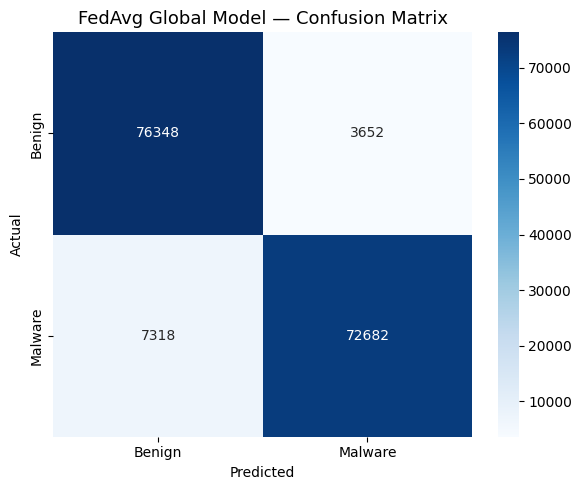

✅ Confusion matrix saved


In [25]:
# ============================================================
# CELL 19 — Confusion Matrix: FedAvg Global Model
# ============================================================
cm_fed = confusion_matrix(y_test, y_pred_fed)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_fed, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'])
plt.title('FedAvg Global Model — Confusion Matrix', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fedavg_confusion_matrix.png', dpi=150)
plt.show()
print('✅ Confusion matrix saved')

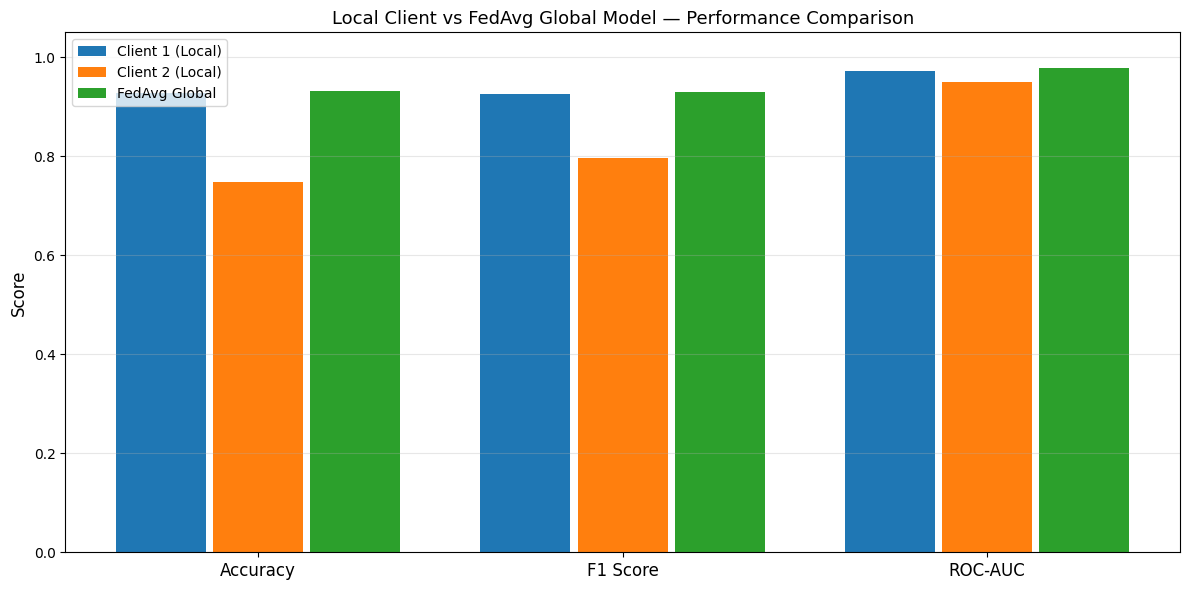

✅ Comparison chart saved


In [26]:
# ============================================================
# CELL 20 — Bar Chart: Local vs Global Performance Comparison
# ============================================================
metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
bar_width = 0.8 / (len(results_df))

fig, ax = plt.subplots(figsize=(12, 6))

for i, row in results_df.iterrows():
    vals = [row['Accuracy'], row['F1 Score'], row['ROC-AUC']]
    offset = (i - len(results_df) / 2) * bar_width + bar_width / 2
    bars = ax.bar(x + offset, vals, bar_width - 0.02, label=row['Model'])

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Local Client vs FedAvg Global Model — Performance Comparison', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/local_vs_global_comparison.png', dpi=150)
plt.show()
print('✅ Comparison chart saved')

In [28]:
# ============================================================
# CELL 21 — SHAP Setup: Create Explainer for Global FedAvg Model
#
# We use shap.DeepExplainer (works best with Keras/TF models).
# Background: small random sample from test set (200 samples).
# Explanation: another sample (500 samples).
# ============================================================
print('Setting up SHAP DeepExplainer...')

# Background dataset: small representative sample
np.random.seed(42)
bg_idx   = np.random.choice(len(X_test_scaled), size=200, replace=False)
X_bg     = X_test_scaled[bg_idx]

# Explanation dataset: separate sample
all_idx  = np.arange(len(X_test_scaled))
exp_idx  = np.random.choice(np.setdiff1d(all_idx, bg_idx), size=500, replace=False)
X_exp    = X_test_scaled[exp_idx]
y_exp    = y_test[exp_idx]

explainer = shap.DeepExplainer(global_model, X_bg)
print('✅ SHAP DeepExplainer ready')

Setting up SHAP DeepExplainer...
✅ SHAP DeepExplainer ready


In [34]:
# ============================================================
# CELL 22 — Compute SHAP Values (FIXED)
# ============================================================
print('Computing SHAP values (this may take a few minutes)...')
shap_values = explainer.shap_values(X_exp)

# Fix: squeeze out extra trailing dimension if present
# DeepExplainer with single sigmoid output sometimes returns (n, features, 1)
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values)
if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values.squeeze(-1)  # (500, 890, 1) → (500, 890)

print(f'✅ SHAP values computed — shape: {shap_values.shape}')  # should be (500, 890)

Computing SHAP values (this may take a few minutes)...
✅ SHAP values computed — shape: (500, 890)


In [33]:
# ============================================================
# CELL 23 — SHAP: Global Feature Importance (Bar Plot)
# ============================================================

# Debug: check what feature_cols actually is
print(f'type(feature_cols)     : {type(feature_cols)}')
print(f'type(feature_cols[0])  : {type(feature_cols[0])}')
print(f'feature_cols[0]        : {feature_cols[0]}')
print(f'len(feature_cols)      : {len(feature_cols)}')
print(f'shap_values.shape      : {shap_values.shape}')
print(f'mean_abs_shap.shape    : {mean_abs_shap.shape}')

type(feature_cols)     : <class 'list'>
type(feature_cols[0])  : <class 'str'>
feature_cols[0]        : byteentropy_0
len(feature_cols)      : 890
shap_values.shape      : (500, 890, 1)
mean_abs_shap.shape    : (890, 1)


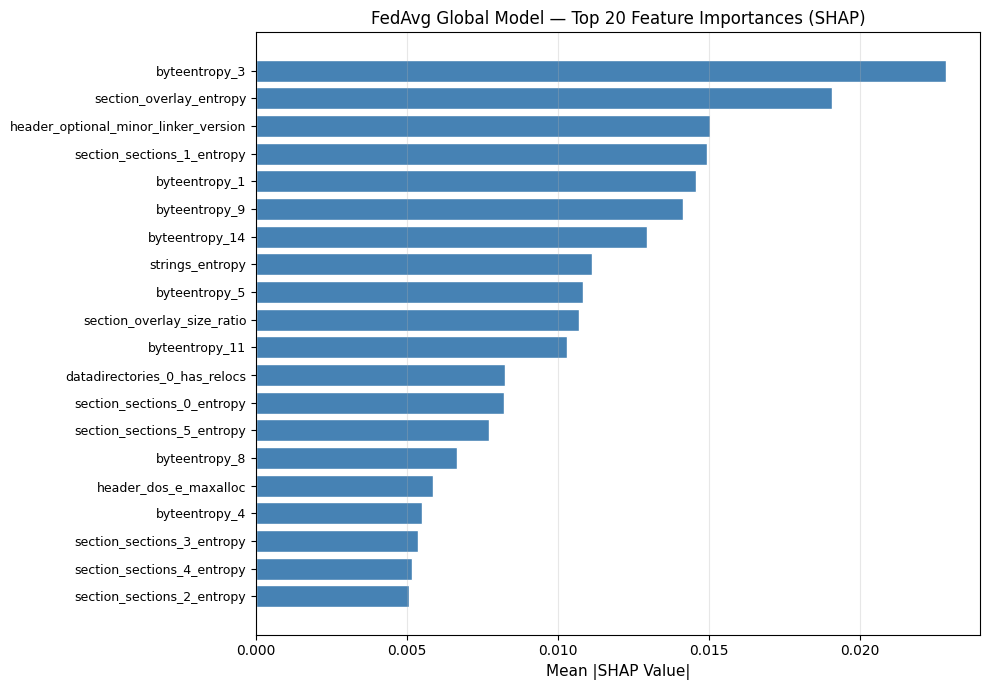

✅ SHAP feature importance bar chart saved


In [35]:
# ============================================================
# CELL 23 — SHAP: Global Feature Importance (Bar Plot)
# ============================================================
mean_abs_shap = np.abs(shap_values).mean(axis=0)  # shape: (n_features,)
top_k = 20

top_idx   = np.argsort(mean_abs_shap)[::-1][:top_k]
top_idx   = top_idx.tolist()  # ← fix: convert numpy array to plain Python list
top_feats = [feature_cols[i] for i in top_idx]
top_vals  = mean_abs_shap[np.array(top_idx)]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(top_k), top_vals[::-1], color='steelblue', edgecolor='white')
ax.set_yticks(range(top_k))
ax.set_yticklabels(top_feats[::-1], fontsize=9)
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title(f'FedAvg Global Model — Top {top_k} Feature Importances (SHAP)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/shap_feature_importance_bar.png', dpi=150)
plt.show()
print('✅ SHAP feature importance bar chart saved')

/tmp/ipykernel_57/1237921802.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


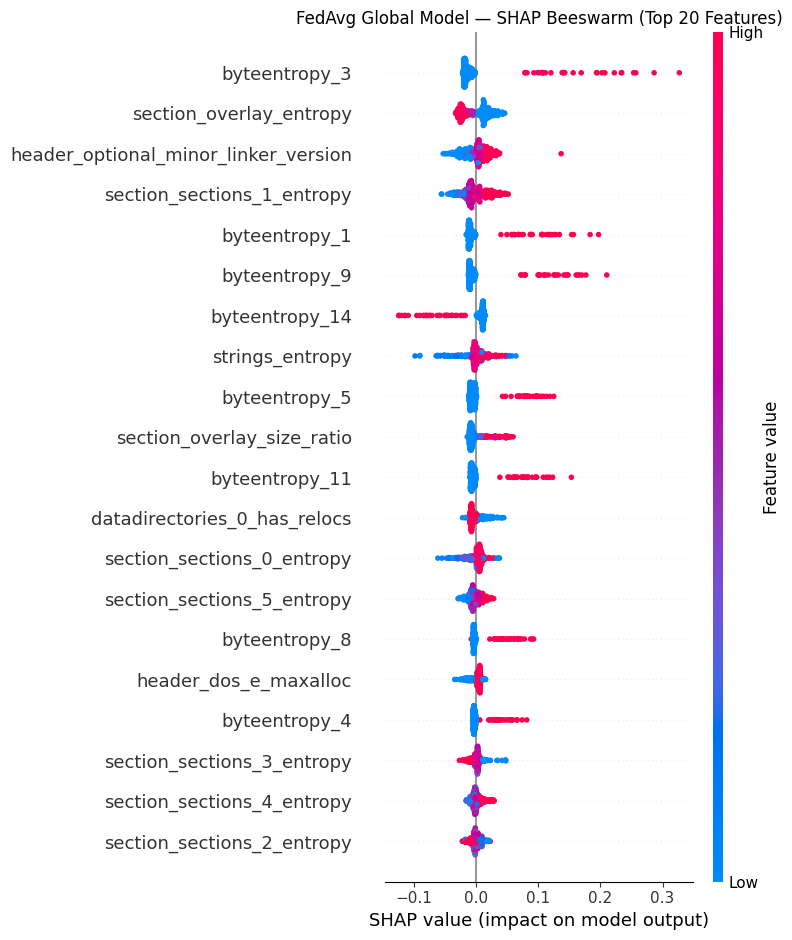

✅ SHAP beeswarm plot saved


In [37]:
# ============================================================
# CELL 24 — SHAP: Summary Beeswarm Plot (Top 20 Features)
# ============================================================
# Select only top-20 feature indices for the beeswarm
top_idx = [int(i) for i in top_idx]
shap_top = shap_values[:, top_idx]
X_exp_top = X_exp[:, top_idx]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_top,
    X_exp_top,
    feature_names=top_feats,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('FedAvg Global Model — SHAP Beeswarm (Top 20 Features)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/shap_beeswarm.png', dpi=150)
plt.show()
print('✅ SHAP beeswarm plot saved')

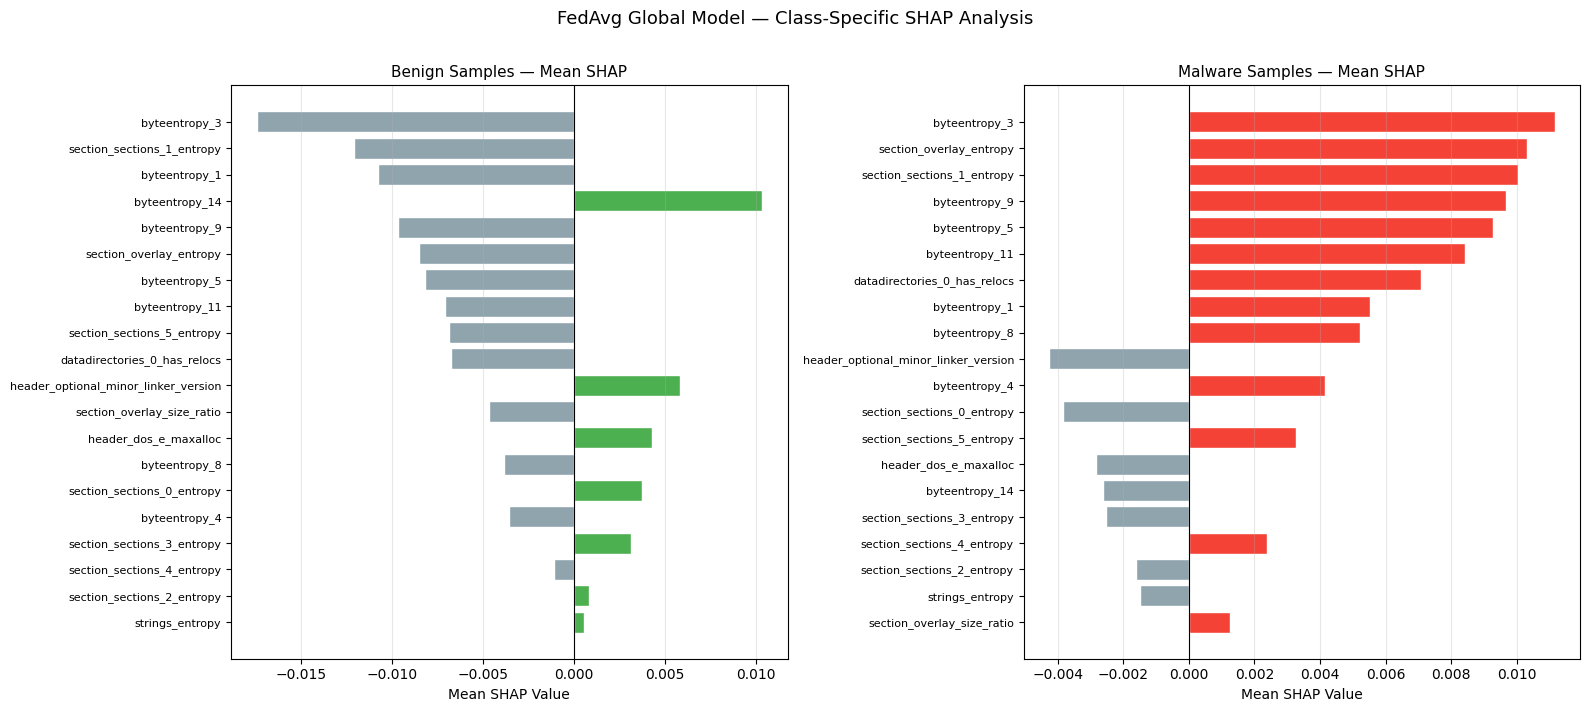

✅ Class-specific SHAP chart saved


In [38]:
# ============================================================
# CELL 25 — SHAP: Class-Specific Analysis (Benign vs Malware)
# ============================================================
top_idx = [int(i) for i in top_idx]
benign_mask  = (y_exp == 0)
malware_mask = (y_exp == 1)

mean_shap_benign  = shap_values[benign_mask,  :][:, top_idx].mean(axis=0)
mean_shap_malware = shap_values[malware_mask, :][:, top_idx].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, vals, title, color in zip(
    axes,
    [mean_shap_benign, mean_shap_malware],
    ['Benign Samples — Mean SHAP', 'Malware Samples — Mean SHAP'],
    ['#4CAF50', '#F44336']
):
    sorted_idx = np.argsort(np.abs(vals))[::-1]
    ax.barh(
        range(len(top_feats)),
        vals[sorted_idx][::-1],
        color=[color if v >= 0 else '#90A4AE' for v in vals[sorted_idx][::-1]],
        edgecolor='white'
    )
    ax.set_yticks(range(len(top_feats)))
    ax.set_yticklabels([top_feats[i] for i in sorted_idx][::-1], fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean SHAP Value', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('FedAvg Global Model — Class-Specific SHAP Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/shap_class_specific.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Class-specific SHAP chart saved')

<Figure size 800x600 with 0 Axes>

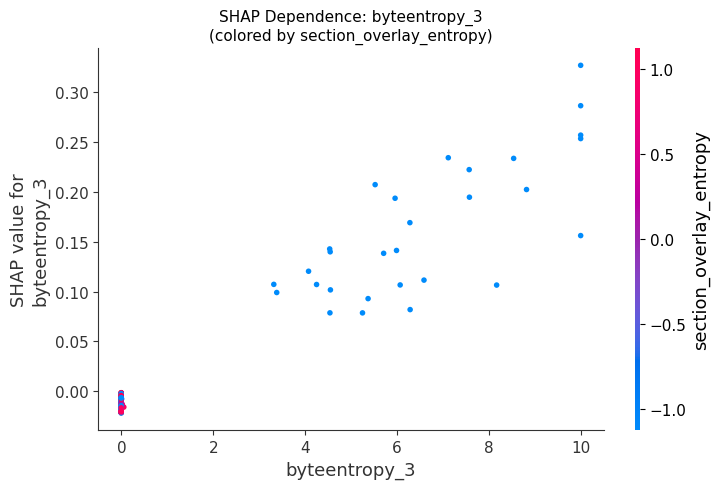

✅ SHAP dependence plot saved


In [39]:
# ============================================================
# CELL 26 — SHAP: Dependence Plot for Top Feature
# Shows interaction between top feature and a key secondary feature
# ============================================================
top_idx = [int(i) for i in top_idx]
top1_name = top_feats[0]
top2_name = top_feats[1]

top1_local_idx = 0  # index in our top_feats / shap_top arrays
top2_local_idx = 1

plt.figure(figsize=(8, 6))
shap.dependence_plot(
    top1_local_idx,
    shap_top,
    X_exp_top,
    feature_names=top_feats,
    interaction_index=top2_local_idx,
    show=False
)
plt.title(f'SHAP Dependence: {top1_name}\n(colored by {top2_name})', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/shap_dependence_top1.png', dpi=150)
plt.show()
print('✅ SHAP dependence plot saved')

/tmp/ipykernel_57/775586437.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  base_val = float(np.array(base_val))  # ← converts TF tensor / numpy scalar safely


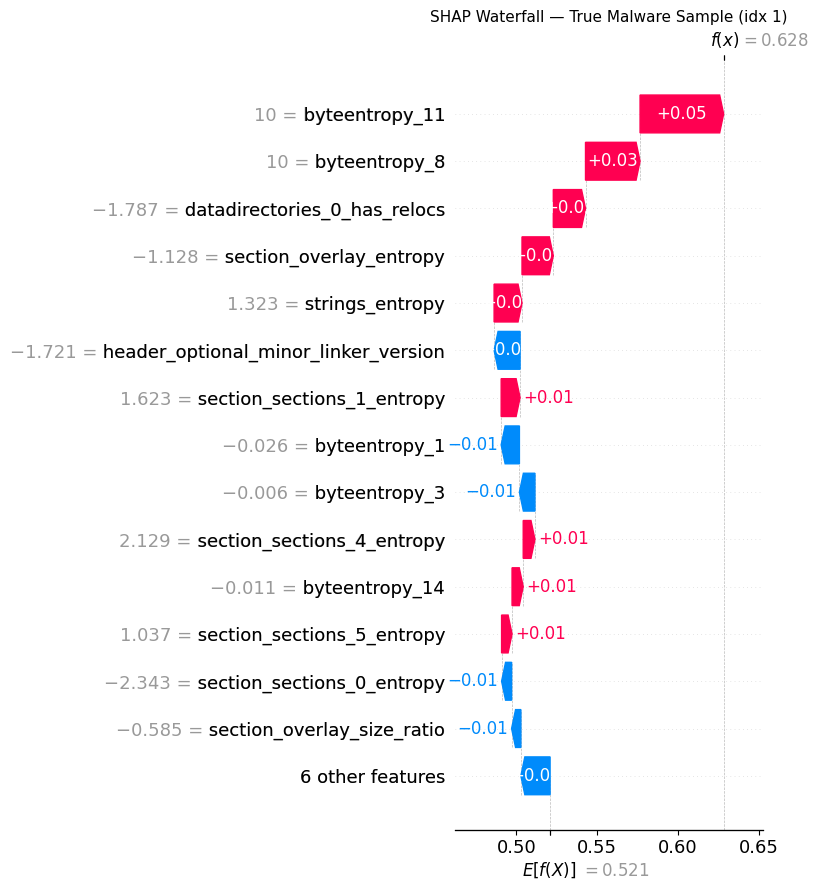

✅ SHAP waterfall (malware) saved


In [43]:
# ============================================================
# CELL 27 — SHAP: Waterfall Plot for a Single Malware Sample (FIXED)
# ============================================================

# Fix: convert expected_value from TF scalar tensor to plain float
base_val = explainer.expected_value
if isinstance(base_val, list):
    base_val = base_val[0]
base_val = float(np.array(base_val))  # ← converts TF tensor / numpy scalar safely

y_pred_exp   = (global_model.predict(X_exp, batch_size=512, verbose=0).ravel() > 0.5).astype(int)
malware_preds = np.where((y_pred_exp == 1) & (y_exp == 1))[0]

if len(malware_preds) > 0:
    sample_idx = malware_preds[0]

    shap_exp = shap.Explanation(
        values        = shap_top[sample_idx],
        base_values   = base_val,
        data          = X_exp_top[sample_idx],
        feature_names = top_feats
    )

    plt.figure(figsize=(10, 7))
    shap.waterfall_plot(shap_exp, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — True Malware Sample (idx {sample_idx})', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/shap_waterfall_malware.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ SHAP waterfall (malware) saved')
else:
    print('⚠️  No true-positive malware sample found in explanation set.')

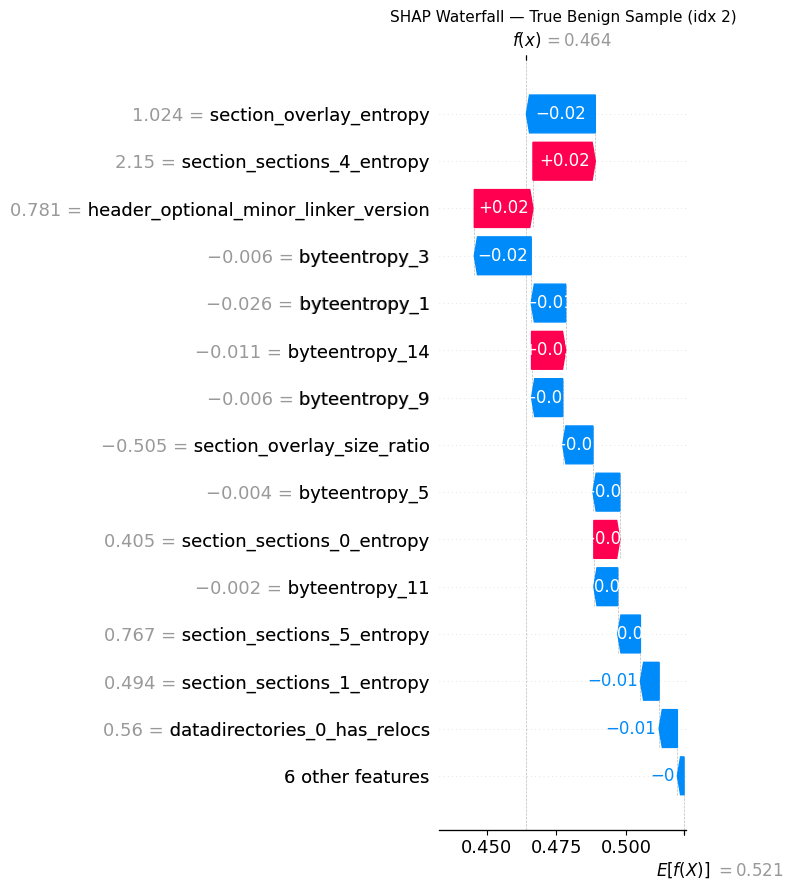

✅ SHAP waterfall (benign) saved


In [44]:
# ============================================================
# CELL 28 — SHAP: Waterfall Plot for a Single Benign Sample (FIXED)
# ============================================================
benign_preds = np.where((y_pred_exp == 0) & (y_exp == 0))[0]

if len(benign_preds) > 0:
    sample_idx_b = benign_preds[0]

    shap_exp_b = shap.Explanation(
        values        = shap_top[sample_idx_b],
        base_values   = base_val,   # ← reuse the same converted float
        data          = X_exp_top[sample_idx_b],
        feature_names = top_feats
    )

    plt.figure(figsize=(10, 7))
    shap.waterfall_plot(shap_exp_b, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — True Benign Sample (idx {sample_idx_b})', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/shap_waterfall_benign.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ SHAP waterfall (benign) saved')
else:
    print('⚠️  No true-negative benign sample found in explanation set.')

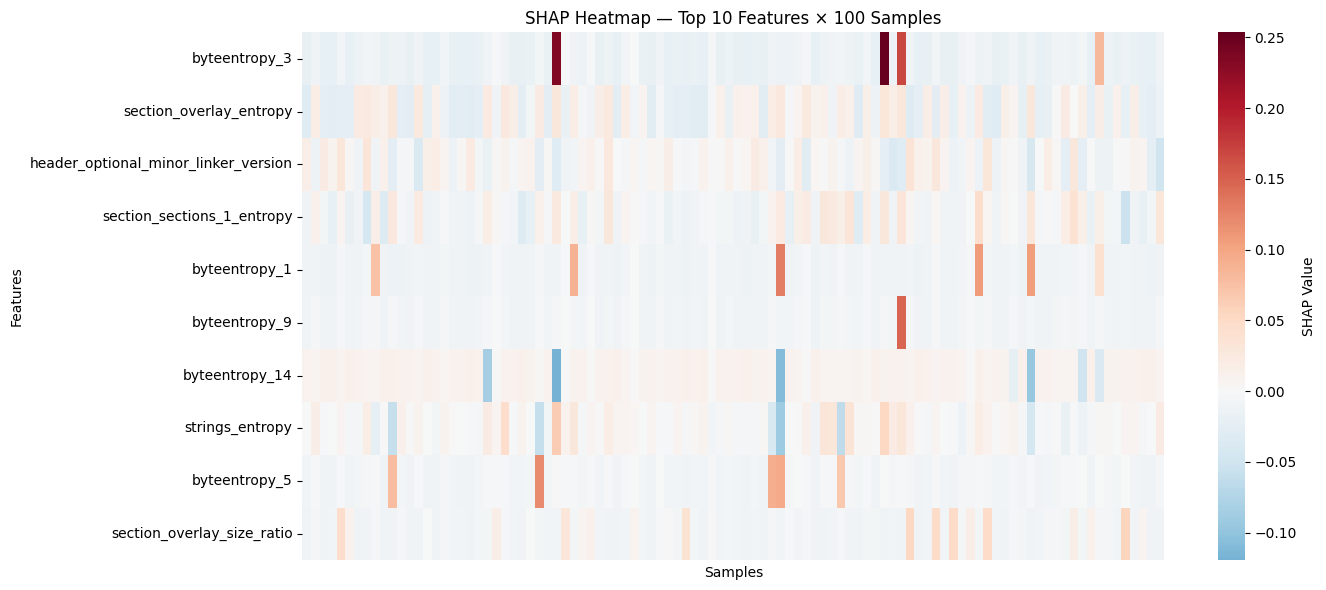

✅ SHAP heatmap saved


In [45]:
# ============================================================
# CELL 29 — SHAP: Heatmap of Top Features Across Samples
# ============================================================
# Show top-10 features across first 100 explanation samples
top_idx = [int(i) for i in top_idx]
top10_idx  = top_idx[:10]
top10_feats = [feature_cols[i] for i in top10_idx]
shap_heatmap_data = shap_values[:100, :][:, top10_idx]

plt.figure(figsize=(14, 6))
sns.heatmap(
    shap_heatmap_data.T,
    cmap='RdBu_r',
    center=0,
    yticklabels=top10_feats,
    xticklabels=False,
    cbar_kws={'label': 'SHAP Value'}
)
plt.title('SHAP Heatmap — Top 10 Features × 100 Samples', fontsize=12)
plt.xlabel('Samples', fontsize=10)
plt.ylabel('Features', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/shap_heatmap.png', dpi=150)
plt.show()
print('✅ SHAP heatmap saved')

In [46]:
# ============================================================
# CELL 30 — Save SHAP Feature Importance to CSV
# ============================================================
shap_importance_df = pd.DataFrame({
    'Feature'          : feature_cols,
    'Mean_Abs_SHAP'    : mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

shap_importance_df.to_csv(f'{OUT_DIR}/shap_feature_importance.csv', index=False)
print('✅ SHAP feature importance CSV saved')
print('\nTop 10 Features by SHAP Importance:')
print(shap_importance_df.head(10).to_string(index=False))

✅ SHAP feature importance CSV saved

Top 10 Features by SHAP Importance:
                             Feature  Mean_Abs_SHAP
                       byteentropy_3       0.022832
             section_overlay_entropy       0.019079
header_optional_minor_linker_version       0.015034
          section_sections_1_entropy       0.014935
                       byteentropy_1       0.014559
                       byteentropy_9       0.014129
                      byteentropy_14       0.012932
                     strings_entropy       0.011138
                       byteentropy_5       0.010825
          section_overlay_size_ratio       0.010700


In [47]:
# ============================================================
# CELL 31 — Save Global FedAvg Model & Artifacts
# ============================================================
# Save full model
global_model.save(f'{OUT_DIR}/fedavg_global_model.keras')

# Save weights only
global_model.save_weights(f'{OUT_DIR}/fedavg_global_weights.weights.h5')

# Save scaler used for this evaluation
joblib.dump(scaler, f'{OUT_DIR}/fedavg_global_scaler.pkl')

# Save feature columns used
with open(f'{OUT_DIR}/fedavg_global_feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

# Save comparison results table
results_df.to_csv(f'{OUT_DIR}/fedavg_local_vs_global_results.csv', index=False)

print('\n✅ All artifacts saved to /kaggle/working/')
print('   fedavg_global_model.keras')
print('   fedavg_global_weights.weights.h5')
print('   fedavg_global_scaler.pkl')
print('   fedavg_global_feature_cols.json')
print('   fedavg_local_vs_global_results.csv')
print('   shap_feature_importance.csv')
print('   shap_feature_importance_bar.png')
print('   shap_beeswarm.png')
print('   shap_class_specific.png')
print('   shap_dependence_top1.png')
print('   shap_waterfall_malware.png')
print('   shap_waterfall_benign.png')
print('   shap_heatmap.png')
print('   fedavg_confusion_matrix.png')
print('   local_vs_global_comparison.png')


✅ All artifacts saved to /kaggle/working/
   fedavg_global_model.keras
   fedavg_global_weights.weights.h5
   fedavg_global_scaler.pkl
   fedavg_global_feature_cols.json
   fedavg_local_vs_global_results.csv
   shap_feature_importance.csv
   shap_feature_importance_bar.png
   shap_beeswarm.png
   shap_class_specific.png
   shap_dependence_top1.png
   shap_waterfall_malware.png
   shap_waterfall_benign.png
   shap_heatmap.png
   fedavg_confusion_matrix.png
   local_vs_global_comparison.png
